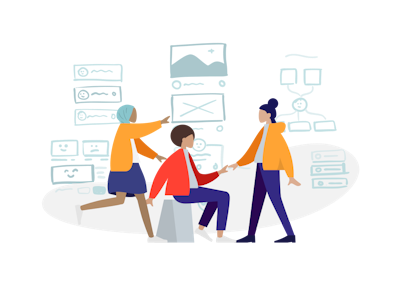

# Análise comparativa de modelos

In [1]:
import pandas as pd
from IPython.display import display, Markdown as md
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer


---

## 1 - Tratamento de dados

In [2]:
df = pd.read_csv("../data/raw/data_tips.csv")
df_dict = pd.read_csv("../data/raw/dictionary_tips.csv")

#Tratamento Quantitativo
coluna_predicao = 'tip'
var_quantitativa = df_dict.query("tipo == 'quantitativa' & variavel != @coluna_predicao").variavel.to_list()

# Tratamento Qualitativo
var_nominal= df_dict.query("subtipo == 'nominal'").variavel.to_list()

df_non_predicao = df.drop(columns=[coluna_predicao], axis=1)

---

In [3]:
#Dataset
display(md("### `DataSet`"))
display(df.head(10))

#Print Dicionario
display(md("### `Dicionário de Dados`"))
display(df_dict)


dado_faltante = df.isnull().any(axis=1).sum()
if dado_faltante != 0:
    display(md("---"))
    display(md(f"Existem `{dado_faltante}` dados faltantes no Dataset."))
    display(md("---"))
else:
    print("Não existe dado faltante no Dataset.")

### `DataSet`

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


### `Dicionário de Dados`

,variavel,descrição,tipo,subtipo
0,total_bill,conta total em dolares,quantitativa,continua
1,tip,gorjeta em dolares,quantitativa,continua
2,sex,gênero do pagante,qualitativa,nominal
3,smoker,existência de fumantes na mesa(sim ou não),qualitativa,nominal
4,day,dia da semana,qualitativa,nominal
5,time,momento da refeição,qualitativa,nominal
6,size,quantidade de pessoas por mesa,quantitativa,discreta


Não existe dado faltante no Dataset.


# Limpeza de Dados

### `Função para reconhecimento de outliers`  

---
`Função outliers:` Qualquer valor menor que o limite inferior será substituído por **lower_bound** e qualquer valor maior que o limite superior será substituído por **upper_bound**

---

In [4]:
# Função para tratamento de outliers usando IQR
def outliers(X):
    Q1 = np.quantile(X, 0.25)
    Q3 = np.quantile(X, 0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(X, lower_bound, upper_bound)

### `Tratamento de dados`

In [5]:
# Pipeline para variáveis quantitativas
quantitativo_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Tratamento de dados faltantes
    ('outlier', FunctionTransformer(outliers, validate=False)),  # Tratamento de outliers
    ('normalization', StandardScaler())  # Normalização
])

# Pipeline para variáveis qualitativas
qualitativo_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Tratamento de dados faltantes
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codificação de variáveis
])

# Combinando pipelines com ColumnTransformer (junta as transformações e aplica de uma vez)
preprocessor = ColumnTransformer([
    ('quantitative', quantitativo_pipeline, var_quantitativa),
    ('qualitative', qualitativo_pipeline, var_nominal)
])